Train Logistic Regression, Decision Tree, and Random Forest classifiers

In [2]:
import pandas as pd

# Load the breast cancer dataset
df = pd.read_csv("breast-cancer.csv")

# Display first 5 rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (569, 32)

Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3 

In [4]:
print(df["diagnosis"].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

# Remove unnecessary ID column
if "id" in df.columns:
    df = df.drop(columns=["id"])

# Convert diagnosis into numerical values
df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

# Separate features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


In [7]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

logistic_train_accuracy = logistic_model.score(X_train, y_train)
logistic_test_accuracy = logistic_model.score(X_test, y_test)

print("Logistic Regression")
print("Train Accuracy:", round(logistic_train_accuracy, 4))
print("Test Accuracy:", round(logistic_test_accuracy, 4))

Logistic Regression
Train Accuracy: 0.9648
Test Accuracy: 0.9386


In [8]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_train_accuracy = tree_model.score(X_train, y_train)
tree_test_accuracy = tree_model.score(X_test, y_test)

print("Decision Tree")
print("Train Accuracy:", round(tree_train_accuracy, 4))
print("Test Accuracy:", round(tree_test_accuracy, 4))

Decision Tree
Train Accuracy: 1.0
Test Accuracy: 0.9298


In [9]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_train_accuracy = forest_model.score(X_train, y_train)
forest_test_accuracy = forest_model.score(X_test, y_test)

print("Random Forest")
print("Train Accuracy:", round(forest_train_accuracy, 4))
print("Test Accuracy:", round(forest_test_accuracy, 4))

Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.9737


In [10]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Train Accuracy": [
        logistic_train_accuracy,
        tree_train_accuracy,
        forest_train_accuracy
    ],
    "Test Accuracy": [
        logistic_test_accuracy,
        tree_test_accuracy,
        forest_test_accuracy
    ]
})

comparison = comparison.round(4)

comparison

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.9648,0.9386
1,Decision Tree,1.0000,0.9298
2,Random Forest,1.0000,0.9737


In [11]:
from sklearn.model_selection import cross_val_score

depths = [2, 3, 4, 5, 6, 8, 10, None]

depth_scores = {}

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    depth_scores[depth] = scores.mean()

print("Cross-validation accuracy by depth:")

for depth, score in depth_scores.items():
    print(depth, ":", round(score, 4))

best_depth = max(depth_scores, key=depth_scores.get)

print("\nBest Tree Depth:", best_depth)
print("Best CV Accuracy:", round(depth_scores[best_depth], 4))

Cross-validation accuracy by depth:
2 : 0.9275
3 : 0.9319
4 : 0.9253
5 : 0.9341
6 : 0.9319
8 : 0.9319
10 : 0.9319
None : 0.9319

Best Tree Depth: 5
Best CV Accuracy: 0.9341


In [12]:
best_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

best_tree.fit(X_train, y_train)

best_tree_train_accuracy = best_tree.score(X_train, y_train)
best_tree_test_accuracy = best_tree.score(X_test, y_test)

print("Optimized Decision Tree")
print("Best Depth:", best_depth)
print("Train Accuracy:", round(best_tree_train_accuracy, 4))
print("Test Accuracy:", round(best_tree_test_accuracy, 4))

Optimized Decision Tree
Best Depth: 5
Train Accuracy: 0.9868
Test Accuracy: 0.9211



 Logistic Regression
[[71  1]
 [ 6 36]]


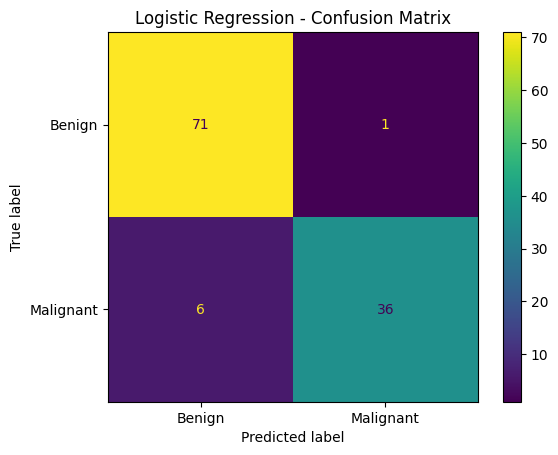


 Optimized Decision Tree
[[70  2]
 [ 7 35]]


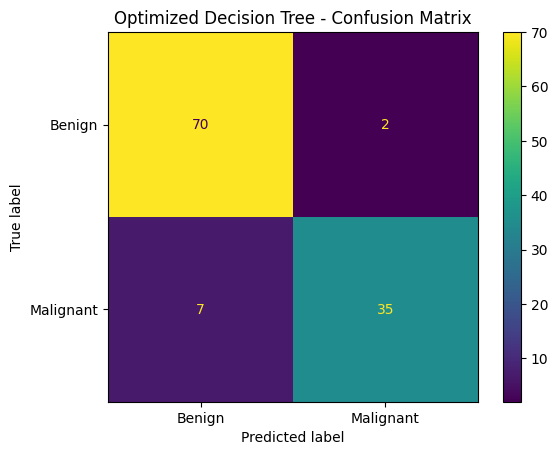


 Random Forest
[[72  0]
 [ 3 39]]


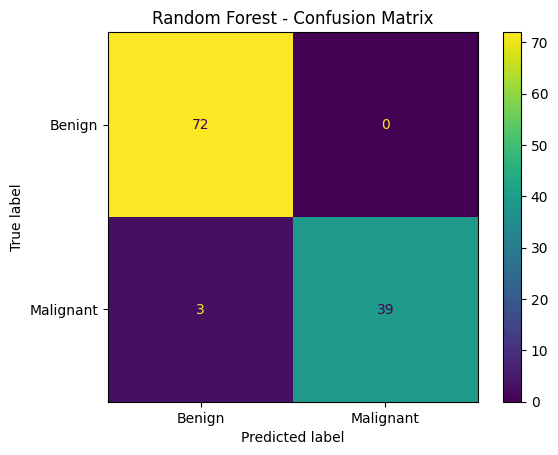

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions from the best-performing model
models = {
    "Logistic Regression": logistic_model,
    "Optimized Decision Tree": best_tree,
    "Random Forest": forest_model
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print("\n", name)
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot()
    plt.title(name + " - Confusion Matrix")
    plt.show()

In [14]:
from sklearn.metrics import classification_report

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Benign", "Malignant"]
        )
    )


Logistic Regression
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114


Optimized Decision Tree
              precision    recall  f1-score   support

      Benign       0.91      0.97      0.94        72
   Malignant       0.95      0.83      0.89        42

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114


Random Forest
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg 

In [15]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Optimized Decision Tree",
        "Random Forest"
    ],
    "Test Accuracy": [
        logistic_test_accuracy,
        best_tree_test_accuracy,
        forest_test_accuracy
    ]
})

final_results = final_results.sort_values(
    by="Test Accuracy",
    ascending=False
)

print("Final Model Ranking:")
display(final_results)

best_model_name = final_results.iloc[0]["Model"]

print("\nBest Performing Model:", best_model_name)

Final Model Ranking:


,Model,Test Accuracy
2,Random Forest,0.973684
0,Logistic Regression,0.938596
1,Optimized Decision Tree,0.921053



Best Performing Model: Random Forest


## OBSERVATION



1. Logistic Regression, Decision Tree, and Random Forest classifiers were trained on the Breast Cancer dataset.

2. The train and test accuracies were compared to evaluate the performance of each model.

3. Cross-validation was performed on Decision Tree models with different maximum depths. The depth with the highest average cross-validation accuracy was selected as the best depth.

4. The optimized Decision Tree was retrained using the best depth obtained from cross-validation.

5. Confusion matrices and classification reports were generated to evaluate the classification performance using precision, recall, and F1-score.

6. The model with the highest test accuracy was considered the best-performing model for this dataset.

7. Comparing train and test accuracy also helps identify whether a model is overfitting or generalizing well to unseen data.

## FINAL CONCLUSION



In this experiment, Logistic Regression, Decision Tree, and Random Forest
classifiers were implemented on the Breast Cancer dataset. Their training
and testing accuracies were compared to evaluate their performance.

Cross-validation was used to determine the most suitable maximum depth for
the Decision Tree classifier. The optimized Decision Tree was then evaluated
on the test dataset.

Confusion matrices and classification reports were used to analyze the
classification results using precision, recall, and F1-score. Based on the
test accuracy, the best-performing model was identified. The experiment
demonstrates the importance of model comparison, cross-validation, and
evaluation metrics in selecting a suitable machine learning model.